## makemore3
#### https://github.com/karpathy/makemore
#### 实现一个基本的MLP （2003）

In [79]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [80]:
words = open('names.txt','r').read().splitlines()
len(words)

32033

In [81]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [82]:
# build the dataset
def build_dataset(words):
    block_size = 3
    X,Y = [],[]
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            idx = stoi[ch]
            X.append(context)
            Y.append(idx)
            # print(''.join(itos[i] for i in context),'--->',itos[idx])
            context = context[1:] + [idx]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

# logits = torch.tensor(Y,dtype = float)
# counts = logits.exp()
# probs = counts / counts.sum(-1,keepdims=True)

In [ ]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xder,Yder = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

In [84]:

g = torch.Generator().manual_seed(42)
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,300),generator=g)
b1 = torch.randn(300,generator=g)
W2 = torch.randn((300,27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C,W1,b1,W2,b2]

sum(p.nelement() for p in parameters)

for p in parameters:
    p.requires_grad = True

In [68]:
# lre = torch.linspace(-3,0,1000)
# lrs = 10**lre

In [93]:
# lri = []
# lossi = []

for k in range(10000):

    # min_batch
    ix = torch.randint(0,Xtr.shape[0],(32,))

    # 向前传播
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts/counts.sum(1,keepdim=True)
    # loss = -porb[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Ytr[ix])
    # print(loss)
    # 向后传播
    for p in parameters:
        p.grad = None
    loss.backward()
    # 更新
    # lr = lrs[k]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    # 记录
    # lri.append(lre[k])
    # lossi.append(loss.item())
    
print(loss.item())

1.6701277494430542


In [70]:
# plt.plot(lri,lossi)

In [94]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.2844, grad_fn=<NllLossBackward0>)

In [95]:
emb = C[Xder]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Yder)
loss

tensor(2.2867, grad_fn=<NllLossBackward0>)

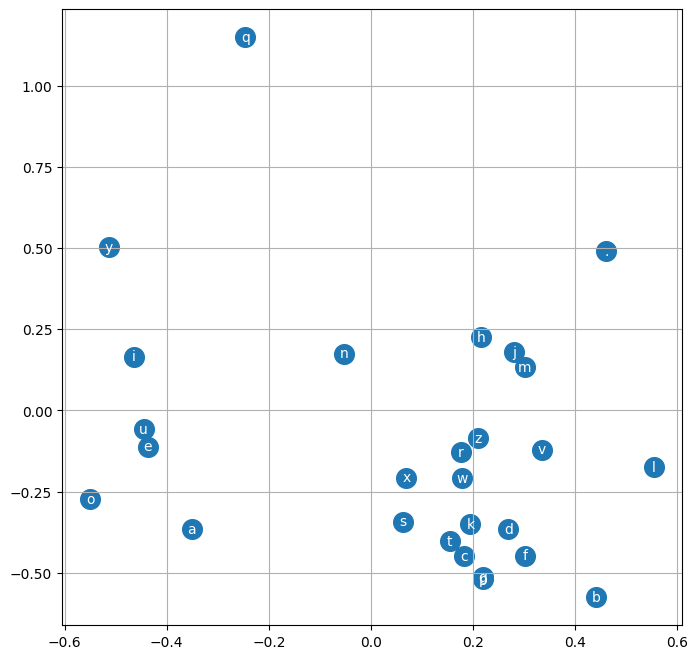

In [96]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data,s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha='center',va='center',color='white')
plt.grid('minor')

In [100]:
# 采样
block_size = 3
g = torch.Generator().manual_seed(42)

for _ in range(10):
    
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits,dim=1)
        ix = torch.multinomial(probs,num_samples=1,generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print("".join(itos[i] for i in out))



anu.
den.
tis.
mabi.
nedante.
nariel.
aleyah.
mah.
lanan.
epiacanden.
